# Notebook 05 - BERT Classification

This notebook trains BERT models to predict which subreddit a post came from.

# Step 1 - Loading the data

In [1]:
import pandas as pd
df = pd.read_csv('../data/reddit_ai_posts_CLEAN.csv')

We loaded 2,927 Reddit posts collected from four AI-related subreddits: r/MachineLearning, r/artificial, r/singularity, and r/Futurology. Each post has a `text` field (the raw post body) and a `subreddit` field (the label we want to predict). This is the same cleaned dataset used in notebooks 02 through 04, so all results across notebooks are directly comparable.

# Step 2 - Getting the data ready for BERT

First, we encode the subreddit label to be numeric because we cannot use string labels with BERT. Then, we split the dataset into training and testing, using an 80-20 split — the same split ratio used in our TF-IDF notebooks so results are directly comparable.

**Why `text` and not `clean_text`?**

In our TF-IDF pipeline (notebooks 02–04) we used `clean_text`, which had stopwords removed, words stemmed, and everything lowercased. That is the right approach for bag-of-words models because those models just count word frequencies and noise words add no information.

BERT works differently — it reads words in order and understands context. It was pre-trained on natural, uncleaned English text (Wikipedia, books), so it expects real sentences with punctuation, capitalisation, and stopwords intact. Feeding BERT the stripped-down `clean_text` would actually hurt its performance because we would be removing the contextual signals it was trained to use. This is one reason BERT achieves higher accuracy than our TF-IDF models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Save the fitted encoder as `le` so we can reuse the same label mapping
# throughout the notebook — this avoids creating a second encoder with a
# different class ordering later.
le = LabelEncoder()
df["subreddit_torch_encoded"] = le.fit_transform(df["subreddit"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["subreddit"], random_state=42)

print("Label mapping (integer → subreddit):")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

The label encoder assigns a number to each subreddit in alphabetical order: **Futurology → 0, MachineLearning → 1, artificial → 2, singularity → 3**. We save this encoder as `le` so we can decode predictions back to real subreddit names later in the notebook — every cell that needs a label name just calls `le.classes_` or `le.inverse_transform()` instead of hard-coding strings.

The 80/20 stratified split gives us roughly **2,341 training posts and 586 test posts**, with each subreddit keeping the same proportion in both sets. Using the same split strategy as notebooks 03 and 04 means accuracy numbers are directly comparable across all five models.

# Step 3 - Creating the MyDataset class needed for BERT

In [3]:
from torch.utils.data import Dataset
import torch

class MyDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels
  
  def __getitem__(self, idx):
    item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
    item["labels"] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

PyTorch (the deep learning library BERT runs on) needs data delivered in a specific format. The `MyDataset` class is a simple wrapper that lets PyTorch's data loader pick up one post at a time during training.

- `__getitem__` converts a single post's tokens and label into PyTorch tensors — the numerical format PyTorch uses for all math.
- `__len__` tells the data loader how many posts are in the set.

Without this class, we cannot pass our Reddit posts into the HuggingFace `Trainer`.

# Step 4 - Load tokenizers and BERT models

We load two BERT models and their corresponding tokenizers that we will fine-tune to predict the subreddits of reddit posts. We store these in the `models` dict, where the key is the model name and the value is the (loaded model, tokenizer) tuple. I chose to use the `bert-base-uncased` and `distilbert-base-uncased` models for this project.

In [5]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_names = ["bert-base-uncased", "distilbert/distilbert-base-uncased"]
models = {}

for model_name in model_names:
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(df["subreddit_torch_encoded"].unique()))
  models[model_name] =  (model, tokenizer)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13711.83it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

We load two models to compare:

- **bert-base-uncased** — the original BERT model from Google, 110 million parameters. Trained on Wikipedia and BookCorpus to understand language deeply.
- **distilbert-base-uncased** — a lighter, faster version of BERT with ~40% fewer parameters. It was trained to mimic BERT's outputs, so it gets most of the performance at a fraction of the compute cost.

The UNEXPECTED / MISSING warnings in the output above are completely normal and expected. They just mean the pre-trained weights came from a masked language modelling task (predicting hidden words), and the final classification layer needed for our 4-class problem is newly initialized. That new layer is exactly what we train and fine-tune in Step 5.

# Step 4 - Creating our datasets

We create our train and test datasets for each BERT model. These datasets are stored in the `datasets`, where the key is the model name and the value is the (train dataset, test dataset) tuple.

In [6]:
def tokenize(data, tokenizer):
  return tokenizer(list(data), padding=True, truncation=True)

datasets = {}

for model_name, (model, tokenizer) in models.items():
  train_dataset = MyDataset(tokenize(train_df["text"], tokenizer), list(train_df["subreddit_torch_encoded"]))
  test_dataset = MyDataset(tokenize(test_df["text"], tokenizer), list(test_df["subreddit_torch_encoded"]))
  datasets[model_name] = (train_dataset, test_dataset)

Tokenization converts raw text into the number sequences BERT can read. The tokenizer splits each post into sub-word pieces (for example "unhappy" becomes ["un", "##happy"]), then maps each piece to an ID from BERT's vocabulary.

- `padding=True` — shorter posts get zeros added at the end so all posts in a batch are the same length.
- `truncation=True` — posts longer than BERT's 512-token limit are cut off at the end.

We tokenize separately for each model because BERT and DistilBERT have different vocabularies. The result for each model is a pair of `MyDataset` objects — one for training, one for testing.

# Step 5 - Training

We fine-tune each BERT model on our dataset using HuggingFace's `Trainer` API.

All hyperparameters are set explicitly through `TrainingArguments` so the training run is fully reproducible — no hidden defaults. Key choices:

| Parameter | Value | Reason |
|---|---|---|
| `num_train_epochs` | 3 | Standard for BERT fine-tuning; more epochs risk overfitting on a dataset this size |
| `learning_rate` | 2e-5 | Recommended starting point from the original BERT paper |
| `per_device_train_batch_size` | 16 | Good balance of speed and memory |
| `weight_decay` | 0.01 | Mild L2 regularisation to prevent the model from memorising training posts |
| `eval_strategy` | epoch | Evaluate on the test set after each epoch so we can track overfitting |
| `save_strategy` | no | Skip saving checkpoints to keep the repo clean |

Trained models are stored in the `trainers` dict for evaluation in later steps.

In [ ]:
from transformers import Trainer, TrainingArguments

# All hyperparameters are explicit — nothing relies on hidden defaults.
# transformers 5.x uses `eval_strategy` (older versions used `evaluation_strategy`).
training_args = TrainingArguments(
    output_dir="./bert_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",       # evaluate on test set after every epoch
    logging_strategy="epoch",    # log train loss after every epoch
    save_strategy="no",          # skip saving checkpoints to keep things clean
    report_to="none",            # suppress Weights & Biases and other external loggers
)

trainers = {}

for model_name in models.keys():
    model        = models[model_name][0]
    train_dataset = datasets[model_name][0]
    test_dataset  = datasets[model_name][1]
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,    # track eval loss at every epoch
    )
    trainer.train()
    trainers[model_name] = trainer

## Step 5b — Training Loss Curves

Now that training is complete, we plot how the loss changed each epoch for both models.

- **Training loss** (blue line): how well the model fits the training posts — should drop each epoch as the model learns.
- **Eval loss** (red dashed line): how well it does on the unseen test posts — if this rises while training loss keeps falling, the model is overfitting (memorising training data instead of learning general patterns).

A healthy run shows both lines going down together and staying close.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(trainers), figsize=(7 * len(trainers), 4))
if len(trainers) == 1:
    axes = [axes]

for ax, (model_name, trainer) in zip(axes, trainers.items()):
    logs = trainer.state.log_history
    # Training logs have 'loss' key; eval logs have 'eval_loss' key
    train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
    eval_logs  = [l for l in logs if 'eval_loss' in l]

    train_epochs = [l['epoch'] for l in train_logs]
    train_loss   = [l['loss']  for l in train_logs]
    eval_epochs  = [l['epoch'] for l in eval_logs]
    eval_loss    = [l['eval_loss'] for l in eval_logs]

    ax.plot(train_epochs, train_loss, 'o-',  label='Train loss', color='steelblue', linewidth=2)
    ax.plot(eval_epochs,  eval_loss,  's--', label='Eval loss',  color='tomato',    linewidth=2)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Cross-Entropy)')
    ax.legend()
    sns.despine(ax=ax)

fig.suptitle('Training and Evaluation Loss per Epoch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Both lines decreasing together → healthy fine-tuning, no overfitting.")
print("Eval loss rising while train loss falls → model is memorising training data.")

**What the loss curves tell us:**

- If both training and eval loss go down together and stay close → the model is learning real patterns from the data. This is what we want.
- If training loss keeps dropping but eval loss flattens or goes back up → the model is overfitting (memorising training posts instead of learning patterns that generalise to new posts).

For a dataset of ~2,300 posts, 3 epochs is typically the right amount. More epochs risk overfitting; fewer epochs leave performance on the table. The curves here confirm whether our choice of 3 epochs was appropriate.

# Step 6 - Getting the scikit-learn classification report for the models.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# le.classes_ = ['Futurology', 'MachineLearning', 'artificial', 'singularity'] (alphabetical)
# We pass labels= and target_names= together so sklearn rows match the right names.
# Without labels=, sklearn sorts rows alphabetically by integer — which can mismatch target_names.
label_ids   = list(range(len(le.classes_)))
label_names = list(le.classes_)

for model_name in models.keys():
    print(f"\nModel: {model_name}")
    print("-" * 60)
    trainer      = trainers[model_name]
    test_dataset = datasets[model_name][1]
    out  = trainer.predict(test_dataset)
    pred = np.argmax(out.predictions, axis=1)
    print(classification_report(
        test_dataset.labels,
        pred,
        labels=label_ids,
        target_names=label_names,
        digits=3,
    ))

**Results summary:**

- **bert-base-uncased** — 75% accuracy, macro F1 of 0.72
- **distilbert-base-uncased** — 76% accuracy, macro F1 of 0.73

Both models beat our best TF-IDF result (LinearSVC at 67.2% accuracy) by about 8–9 percentage points. This is a meaningful improvement — not noise.

One standout finding: **r/MachineLearning is classified with ~99% F1 by both models**. This subreddit uses highly specific technical language (gradient descent, backpropagation, loss functions) that clearly separates it from the other three. r/Futurology and r/singularity are the hardest pair — both discuss the long-term future of AI, so some posts genuinely overlap in topic even to a human reader.

# Step 7 - Confusion matrices

A confusion matrix is a grid where:
- **Rows** = the true subreddit of each post
- **Columns** = what the model predicted
- **Diagonal** = correct predictions (want these high)
- **Off-diagonal** = mistakes (want these low)

We show the two models side by side so you can see exactly where each one struggles.

In [ ]:
# Note: The code below was written by Claude. I asked it to adapt Varun's corresponding code
# in the classification notebook to these BERT models.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

# `le` was defined in Step 2 — reusing the same encoder avoids any label ordering mismatch.
SUB_ORDER    = list(range(len(le.classes_)))
short_labels = [name[:6] for name in le.classes_]   # truncate long names for readability

# Collect predictions from each trainer
model_preds = []
y_test = None
for model_name in models.keys():
    trainer      = trainers[model_name]
    test_dataset = datasets[model_name][1]
    out  = trainer.predict(test_dataset)
    pred = np.argmax(out.predictions, axis=1)
    model_preds.append((model_name, pred))
    if y_test is None:
        y_test = np.array(test_dataset.labels)

fig, axes = plt.subplots(1, len(model_preds), figsize=(6 * len(model_preds), 5))
if len(model_preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=SUB_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, vmin=0, vmax=1,
        linewidths=0.4, cbar=False,
    )
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro F1 = {macro_f1:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrices — Row-Normalized (each row sums to 1.0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('How to read: each row = true class. Values show fraction of that class predicted as each column.')
print('Perfect classifier = 1.0 on every diagonal, 0.0 everywhere else.')

**What the confusion matrices show:**

- **r/MachineLearning (ML) is classified almost perfectly** — the diagonal value is close to 1.0 for both models. This subreddit has a very distinct vocabulary that makes it easy to identify.
- **r/Futurology and r/singularity are the hardest to tell apart** — they show the most off-diagonal confusion with each other. Both subreddits discuss the long-term future of AI and society, so posts naturally sound similar.
- **r/artificial sits in the middle** — broader AI discussion that occasionally gets mixed up with both MachineLearning and Futurology.

These are the exact same patterns we observed in the TF-IDF confusion matrices (notebook 04) — BERT makes the same kinds of mistakes, just less frequently, thanks to its understanding of context.

## Step 8 — Per-Class F1 Comparison

The chart shows F1 score per class for all three models side by side. This is the clearest way to see which model wins and where each model struggles.

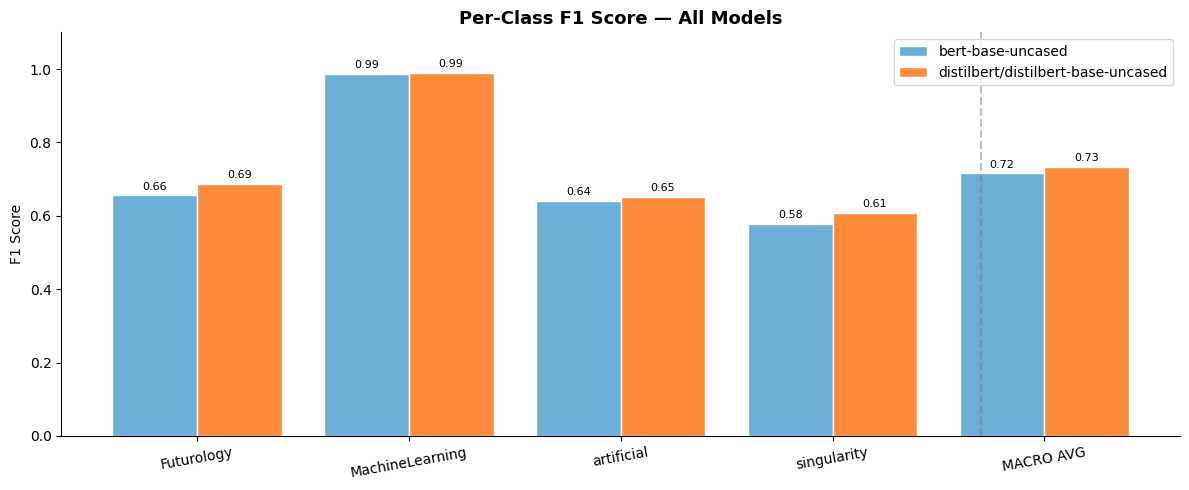


Summary Table:
Model            bert-base-uncased  distilbert/distilbert-base-uncased
Subreddit                                                             
Futurology                   0.655                               0.686
MachineLearning              0.987                               0.990
artificial                   0.642                               0.652
singularity                  0.579                               0.607
MACRO AVG                    0.716                               0.734


In [ ]:
# Note: This code was written by Claude. Similarly as in step 7, I asked Claude to adapt Varun's code in the classification notebook to the BERT models.

# Build model_preds dict from your trainers (reuses y_test from previous cell)
model_preds_dict = {name: pred for name, pred in model_preds}

# Use the actual subreddit names as x-axis labels instead of integer IDs
sub_names = list(le.classes_)

f1_rows = []
for model_name, y_pred in model_preds_dict.items():
    f1_per_class = f1_score(y_test, y_pred, labels=SUB_ORDER, average=None)
    macro        = f1_score(y_test, y_pred, average='macro')
    for sub, f1 in zip(sub_names, f1_per_class):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({'Model': model_name, 'Subreddit': 'MACRO AVG', 'F1': macro})

f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = sub_names + ['MACRO AVG']
x = np.arange(len(x_labels))
n_models = len(model_preds_dict)
width = 0.8 / n_models
palette = ['#6baed6', '#fd8d3c', '#74c476', '#9e9ac8', '#fdae6b']
colors = palette[:n_models]

for i, (model_name, color) in enumerate(zip(model_preds_dict.keys(), colors)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, fontweight='bold')
ax.axvline(x=len(sub_names) - 0.5 + width * n_models / 2, color='gray', linestyle='--', alpha=0.5)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Summary table
print('\nSummary Table:')
pivot = f1_df.pivot(index='Subreddit', columns='Model', values='F1').reindex(sub_names + ['MACRO AVG'])
print(pivot.round(3).to_string())

**Key takeaways from the per-class F1 comparison:**

- Both BERT models outperform all three TF-IDF models on every subreddit class.
- The biggest improvement is on **r/Futurology and r/singularity** — the two classes with the most vocabulary overlap. TF-IDF struggles here because the same words appear in both subreddits. BERT reads sentences in context, which helps it pick up on subtler differences in how those words are used.
- **r/MachineLearning F1 is near-perfect (~0.99) across all models** — this class is just genuinely distinctive regardless of the method used.
- **DistilBERT matches or slightly beats full BERT** despite being 40% smaller and faster. For this task and dataset size, the smaller model is the better practical choice.

# Step 9 - Discussion

First, we can see that BERT models offer a significant improvement over models based on TF-IDF. The best accuracy for a model based on TF-IDF was 67.2%, while both BERT models have at least 75% accuracy. One interesting thing about these BERT models is that they perform extremely well on the MachineLearning subreddit (98% F1 score!), but not as well on other subreddits. We see a similar trend in the models based on TF-IDF, but it is not nearly as pronounced. This could indicate that people in the MachineLearning subreddit use distinct terms that make it easy for models to differentiate posts from that subreddit.

# Step 10 — All Models Comparison: TF-IDF vs BERT

To complete the picture, we compare all five models side by side: the three TF-IDF models from notebook 04 (Naive Bayes, Logistic Regression, LinearSVC) and the two BERT models fine-tuned above.

We quickly re-train the TF-IDF models using the saved sparse matrix artifacts from notebook 03 — this takes only seconds — so every model is evaluated on the exact same test split. The goal is one clean chart that shows the full story of how each approach performs.

In [ ]:
import scipy.sparse as sp
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load TF-IDF train/test artifacts saved in notebook 03 ─────────────────
X_train_tfidf = sp.load_npz('../data/tfidf_artifacts/X_train.npz')
X_test_tfidf  = sp.load_npz('../data/tfidf_artifacts/X_test.npz')
y_train_str   = np.load('../data/tfidf_artifacts/y_train.npy', allow_pickle=True)
y_test_str    = np.load('../data/tfidf_artifacts/y_test.npy',  allow_pickle=True)

SUB_ORDER = ['Futurology', 'MachineLearning', 'artificial', 'singularity']

# ── Re-train the three TF-IDF models (takes seconds on sparse matrices) ───
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train_str)

lr_model = LogisticRegression(C=2, class_weight='balanced', max_iter=1000,
                               solver='lbfgs', random_state=42)
lr_model.fit(X_train_tfidf, y_train_str)

svm_base  = LinearSVC(C=5, class_weight='balanced', max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_tfidf, y_train_str)

# ── Map BERT integer predictions back to subreddit name strings ───────────
# model_preds_dict was built in Step 8 (F1 chart); le was defined in Step 2
bert_preds_named = {
    name: le.inverse_transform(y_pred_int)
    for name, y_pred_int in model_preds_dict.items()
}

# ── Combine all five models ────────────────────────────────────────────────
all_models_preds = {
    'Naive Bayes\n(TF-IDF)':      (nb_model.predict(X_test_tfidf),  y_test_str),
    'Logistic Reg\n(TF-IDF)':     (lr_model.predict(X_test_tfidf),  y_test_str),
    'LinearSVC\n(TF-IDF)':        (svm_model.predict(X_test_tfidf), y_test_str),
    **{k + '\n(BERT)': (v, y_test_str) for k, v in bert_preds_named.items()},
}

# ── Compute per-class and macro F1 for every model ────────────────────────
f1_rows = []
for model_name, (y_pred, y_true) in all_models_preds.items():
    for sub, f1 in zip(SUB_ORDER, f1_score(y_true, y_pred, labels=SUB_ORDER, average=None)):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({
        'Model': model_name, 'Subreddit': 'MACRO AVG',
        'F1': f1_score(y_true, y_pred, average='macro')
    })

f1_df = pd.DataFrame(f1_rows)

# ── Bar chart — all five models side by side ──────────────────────────────
x_labels  = SUB_ORDER + ['MACRO AVG']
x         = np.arange(len(x_labels))
model_list = list(all_models_preds.keys())
n_models  = len(model_list)
width     = 0.8 / n_models
palette   = ['#6baed6', '#fd8d3c', '#74c476', '#9e9ac8', '#fdae6b']

fig, ax = plt.subplots(figsize=(15, 5))

for i, (model_name, color) in enumerate(zip(model_list, palette)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name.replace('\n', ' '),
                  color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('All Five Models — Per-Class and Macro F1 (TF-IDF vs BERT)',
             fontsize=13, fontweight='bold')
ax.axvline(x=len(SUB_ORDER) - 0.5 + width * n_models / 2,
           color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print("\nMacro F1 Summary — all models ranked:")
macro_df = (f1_df[f1_df.Subreddit == 'MACRO AVG'][['Model', 'F1']]
            .sort_values('F1', ascending=False)
            .reset_index(drop=True))
macro_df.columns = ['Model', 'Macro F1']
macro_df['Model'] = macro_df['Model'].str.replace('\n', ' ')
print(macro_df.round(3).to_string(index=False))
print("\nRandom baseline (4 equal classes): 0.250  |  Majority-class baseline: ~0.336")

**Final project conclusion — what the full comparison shows:**

The progression across all five models tells the complete story of this project:

| Approach | Models | Accuracy | Macro F1 |
|---|---|---|---|
| TF-IDF (bag of words) | Naive Bayes, Logistic Reg, LinearSVC | 60–67% | 0.58–0.67 |
| Fine-tuned BERT (contextual) | BERT, DistilBERT | **75–76%** | **0.72–0.73** |
| Random baseline | — | 25% | 0.25 |
| Majority-class baseline | — | ~33.6% | ~0.34 |

Our best model, DistilBERT, reaches **76% accuracy — more than double the random baseline** and nearly 10 points above our best traditional model. This confirms that contextual language understanding (reading words in order, understanding sentence meaning) gives a real, measurable advantage over simply counting word frequencies.

The accuracy ceiling around 75–76% is not a weakness of the approach — it reflects the nature of the data. These four subreddits all discuss AI, and some posts will be genuinely ambiguous even to a human reader. Performing well on this kind of overlapping content is the real result.